In [2]:
import networkx as nx
import numpy as np
from scipy.io import mmread
import pandas as pd
import matplotlib.cm as cmx
import matplotlib.colors as colors

from sklearn import metrics
import matplotlib.pyplot as plt
import copy
import scipy.sparse as sp
import scanpy as sc
import os
import anndata as ad
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [3]:
gene_TCR = ad.read_h5ad('./10Xdatasets/gex_merge_log1_5000_genes_all_peptides.h5ad')
gene_TCR.obs['used_ix'] = range(gene_TCR.shape[0])
donor_1234 = gene_TCR
donor_1234

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 145479 × 5000
    obs: 'v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA', 'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB', 'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor', 'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA', 'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b', 'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV', 'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer', 'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer', 'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer', 'A0201_KVLEYVIKV_MAGE-A1_Cancer', 'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase', 'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91', 'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV', 'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza', 'A0201_GLCTLVAML_BMLF1_EBV', 'A0201_NLVPMVATV_pp65_CMV', 'A0201_I

In [4]:
data_10X_dat = donor_1234.obs
data_10X_dat

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,B0702_GPAESAAGL_NC,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0
CTTGGCTTCGTTGCCT-25,TRAV23DV6,TRBV7-2,None,TRBD1,TRAJ48,TRBJ2-5,TRAC,TRBC2,CAAILFGNEKLTF,CASSLFDSQETQYF,...,0.0,0.0,unknown,nan,1,4585.0,3.661339,1382,0.063250,1
ACGATACTCGCAGGCT-40,TRAV9-2,TRBV7-6,None,TRBD2,TRAJ49,TRBJ2-3,TRAC,TRBC2,CALSADTGNQFYF,CASSLFDSGRLDTQYF,...,0.0,0.0,unknown,nan,2,3742.0,3.573104,1279,0.067611,2
ACGCCAGTCATGTCTT-8,TRAV12-3,TRBV20-1,None,TRBD1,TRAJ32,TRBJ2-7,TRAC,TRBC2,CAMNPAWGGATNKLIF,CSASPGDYEQYF,...,0.0,0.0,unknown,nan,4,4368.0,3.640283,1669,0.054716,3
TTCTTAGCAAAGAATC-4,TRAV13-2,TRBV4-1,None,TRBD2,TRAJ37,TRBJ2-1,TRAC,TRBC2,CAETALGNTGKLIF,CASSHGKGGNEQFF,...,0.0,0.0,unknown,nan,5,9129.0,3.960423,2683,0.044035,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAAGCAGAGCAGGCTA-3,TRAV22,TRBV24-1,None,TRBD2,TRAJ47,TRBJ2-2,TRAC,TRBC2,CAVEPLYGNKLVF,CATSDRLAGGELFF,...,0.0,0.0,unknown,nan,159412,1547.0,3.189490,789,0.135747,145474
CAGTCCTTCATCACCC-8,TRAV29DV5,TRBV7-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAATHASGYDKVIF,CASSYLAGDFTDTQYF,...,0.0,0.0,unknown,nan,159414,3934.0,3.594834,1468,0.041688,145475
GACTACACACGGTAAG-3,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159415,4267.0,3.630123,1646,0.047574,145476


In [5]:
from sklearn.decomposition import NMF

In [6]:
# model_nmf = NMF(n_components=100, init='random', random_state=0)
# model_nmf.fit(donor_4.X)

In [7]:
# W = model_nmf.transform(donor_4.X)
# H = model_nmf.components_

In [8]:
# W_df = pd.DataFrame(W)

In [9]:
# W_df

In [25]:
# all_embeddings_df = pd.read_csv('./data_10X_full_data_emb_dat_mvTCR_clean_PCAs_041.csv')
all_embeddings_df_alpha_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_alpha_chain_10X_donor_4_only.csv')
all_embeddings_df_beta_chain = pd.read_csv('./minervina/integration_pred_new_method_gex_to_TCR_beta_chain_10X_all_peptides_225_donor_concat_03032026.csv')


In [26]:
all_embeddings_df_beta_chain

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,0.000000,0.0000,0.000000,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,102.337920,0.00000,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1,67.945330,0.0000,0.000000,0.00000,35.47255,0.0,0.0,0.000000,0.00000,0.0,...,0.000000,0.00000,0.0,0.00000,0.000000,0.0,0.0,19.417398,0.000000,0.000000
2,25.923313,0.0000,0.000000,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,0.000000,0.00000,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
3,0.000000,0.0000,0.000000,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,61.579628,0.00000,0.0,0.00000,0.000000,0.0,0.0,48.461872,0.000000,0.000000
4,42.633920,0.0000,0.000000,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,0.000000,0.00000,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145474,0.000000,0.0000,83.636475,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,0.000000,108.50002,0.0,115.58077,166.173480,0.0,0.0,71.598200,0.000000,0.000000
145475,15.489287,0.0000,82.227960,85.61045,0.00000,0.0,0.0,161.260820,0.00000,0.0,...,0.000000,0.00000,0.0,0.00000,218.587600,0.0,0.0,0.000000,0.000000,62.542667
145476,0.000000,208.6073,189.220610,269.77432,0.00000,0.0,0.0,19.516222,100.87834,0.0,...,0.000000,0.00000,0.0,0.00000,0.000000,0.0,0.0,0.000000,55.067757,68.850570
145477,0.000000,0.0000,101.666340,159.80428,0.00000,0.0,0.0,189.779170,125.37399,0.0,...,0.000000,0.00000,0.0,0.00000,56.488537,0.0,0.0,0.000000,0.000000,0.000000


In [27]:

# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain, W_df], axis=1)
# all_embed = pd.concat([all_embeddings_df_alpha_chain,all_embeddings_df_beta_chain], axis=1)
all_embed = all_embeddings_df_beta_chain
all_embed

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,0.000000,0.0000,0.000000,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,102.337920,0.00000,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1,67.945330,0.0000,0.000000,0.00000,35.47255,0.0,0.0,0.000000,0.00000,0.0,...,0.000000,0.00000,0.0,0.00000,0.000000,0.0,0.0,19.417398,0.000000,0.000000
2,25.923313,0.0000,0.000000,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,0.000000,0.00000,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
3,0.000000,0.0000,0.000000,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,61.579628,0.00000,0.0,0.00000,0.000000,0.0,0.0,48.461872,0.000000,0.000000
4,42.633920,0.0000,0.000000,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,0.000000,0.00000,0.0,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145474,0.000000,0.0000,83.636475,0.00000,0.00000,0.0,0.0,0.000000,0.00000,0.0,...,0.000000,108.50002,0.0,115.58077,166.173480,0.0,0.0,71.598200,0.000000,0.000000
145475,15.489287,0.0000,82.227960,85.61045,0.00000,0.0,0.0,161.260820,0.00000,0.0,...,0.000000,0.00000,0.0,0.00000,218.587600,0.0,0.0,0.000000,0.000000,62.542667
145476,0.000000,208.6073,189.220610,269.77432,0.00000,0.0,0.0,19.516222,100.87834,0.0,...,0.000000,0.00000,0.0,0.00000,0.000000,0.0,0.0,0.000000,55.067757,68.850570
145477,0.000000,0.0000,101.666340,159.80428,0.00000,0.0,0.0,189.779170,125.37399,0.0,...,0.000000,0.00000,0.0,0.00000,56.488537,0.0,0.0,0.000000,0.000000,0.000000


In [26]:
import anndata as ad

In [34]:
donor_1_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           
donor_2_peptides = ['B0801_RAKFKQLL_BZLF1_EBV_binder',            
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A0201_GLCTLVAML_BMLF1_EBV_binder',          
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder']      
donor_3_peptides = ['A0301_KLGGALQAK_IE-1_CMV_binder',           
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',        
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'B0801_RAKFKQLL_BZLF1_EBV_binder']            
donor_4_peptides = ['A1101_IVTDFSVIK_EBNA-3B_EBV_binder',         
         'A0301_KLGGALQAK_IE-1_CMV_binder',            
         'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',       
         'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',         
         'A0201_ELAGIGILTV_MART-1_Cancer_binder',      
         'A0201_GILGFVFTL_Flu-MP_Influenza_binder',    
         'A0201_GLCTLVAML_BMLF1_EBV_binder']           

In [35]:
donor_all_peptides = list(set(donor_1_peptides + donor_2_peptides + donor_3_peptides + donor_4_peptides))
donor_all_peptides

['A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder']

In [ ]:
['A0301_KLGGALQAK_IE-1_CMV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder']

['A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder']

In [14]:
top16_peptide = data_10X_dat.antigen.value_counts().index.to_list()
top16_peptide

['unknown',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder',
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder',
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_LLFGYPVYV_HTLV-1_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A2402_AYAQKIFKI_IE-1_CMV_binder',
 'A0201_KTWGQYWQV_gp100_Cancer_binder',
 'A0201_YLLEMLWRL_LMP1_EBV_binder',
 'A0201_IMDQVPFSV_gp100_Cancer_binder',
 'A2402_QYDPVAALF_pp65_CMV_binder',
 'A2402_CYTWNQMNL_WT1-(235-243)236M_Y_binder',
 'A0201_MLDLQPETT_16E7_HPV_binder',
 'A0201_KVLEYVIKV_MAGE-A1_Cancer_binder',
 'A0201_RMFPNAPYL_WT-1_binder',
 'A0201_YLNDHLEPWI_BCL-X_Cancer_binder',
 'B3

In [15]:
data_10X_dat.columns

Index(['v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA',
       'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB',
       'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor',
       'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA',
       'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b',
       'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV',
       'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer',
       'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer',
       'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer',
       'A0201_KVLEYVIKV_MAGE-A1_Cancer',
       'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase',
       'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91',
       'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV',
       'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza',
       'A0201_GLCTLVAML_BML

In [16]:
top16_peptide[1:10]

['A0301_KLGGALQAK_IE-1_CMV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder']

In [17]:
bind_list = top16_peptide[1:10]
bind_list.append('unknown')
bind_list

['A0301_KLGGALQAK_IE-1_CMV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder',
 'unknown']

In [18]:
from distinctipy import distinctipy

colors_distinct = distinctipy.get_colors(len(bind_list)-1)


In [19]:
colors_distinct.append((0.75,0.75,0.75))
colors_distinct

[(0.09550077853540295, 0.996684681849356, 0.06811044451605075),
 (1.0, 0.0, 1.0),
 (0.0, 0.5, 1.0),
 (1.0, 0.5, 0.0),
 (0.5, 0.25, 0.5),
 (0.35679133808249686, 0.9663923280297649, 0.7232509902194895),
 (0.7746272341532514, 0.9962989301786018, 0.19410109460940816),
 (0.9395371864644332, 0.5112215962417697, 0.862140320468957),
 (1.0, 0.0, 0.0),
 (0.75, 0.75, 0.75)]

In [20]:
antigen_colors = dict(map(lambda i,j : (i,j) , bind_list,colors_distinct))
antigen_colors

{'A0301_KLGGALQAK_IE-1_CMV_binder': (0.09550077853540295,
  0.996684681849356,
  0.06811044451605075),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (1.0, 0.0, 1.0),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.0, 0.5, 1.0),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (1.0, 0.5, 0.0),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.5, 0.25, 0.5),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (0.35679133808249686,
  0.9663923280297649,
  0.7232509902194895),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.7746272341532514,
  0.9962989301786018,
  0.19410109460940816),
 'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.9395371864644332,
  0.5112215962417697,
  0.862140320468957),
 'A0201_FLYALALLL_LMP2A_EBV_binder': (1.0, 0.0, 0.0),
 'unknown': (0.75, 0.75, 0.75)}

In [21]:
top16_peptide[1:10]

['A0301_KLGGALQAK_IE-1_CMV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder']

In [79]:

from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_1234
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_all_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([25, 30,35]):
    for resolution in [ 0.3, 0.4, 0.5, 0.6, 0.7]:
        for n_neighbors in [5, 10, 15, 20, 25, 30]:
            sc.pp.neighbors(adata_gene, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_gene, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_gene.obs['leiden'].astype('int').values,
                adata_gene.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
  0%|          | 0/3 [00:00<?, ?it/s]

Resolution: 0.3, N_neighbors: 5, NMI Score: 0.3897530053757273, PCs: 25
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.3972522081159639, PCs: 25
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.4022456138327467, PCs: 25
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.40197534393057244, PCs: 25
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.4021357675533256, PCs: 25
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.38798682632801973, PCs: 25
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.37399615738475744, PCs: 25
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.3779463286402848, PCs: 25
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.3923471595796218, PCs: 25
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.38865911543722415, PCs: 25
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.3915640673804233, PCs: 25
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.40106183049759303, PCs: 25
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.3743032029782775, PCs: 25
Resolution: 0.5, N_neighbors: 10, NMI Score: 0.37

 33%|███▎      | 1/3 [35:15<1:10:31, 2115.78s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.3687523642207868, PCs: 25
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.3953399574454621, PCs: 30
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.39231883477300655, PCs: 30
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.4015983739599659, PCs: 30
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.40295312752996565, PCs: 30
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.4053728473803565, PCs: 30
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.4045000131806152, PCs: 30
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.3766488402877867, PCs: 30
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.3983578681434876, PCs: 30
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.406266142734845, PCs: 30
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.39270926179809007, PCs: 30
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.3955639085650137, PCs: 30
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.4011402977132949, PCs: 30
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.38350

 67%|██████▋   | 2/3 [1:12:19<36:19, 2179.13s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.37875170681888376, PCs: 30
Resolution: 0.3, N_neighbors: 5, NMI Score: 0.3879989907163865, PCs: 35
Resolution: 0.3, N_neighbors: 10, NMI Score: 0.4133621840873308, PCs: 35
Resolution: 0.3, N_neighbors: 15, NMI Score: 0.4046533911435235, PCs: 35
Resolution: 0.3, N_neighbors: 20, NMI Score: 0.4010335281078422, PCs: 35
Resolution: 0.3, N_neighbors: 25, NMI Score: 0.4039077177843261, PCs: 35
Resolution: 0.3, N_neighbors: 30, NMI Score: 0.4019607000974675, PCs: 35
Resolution: 0.4, N_neighbors: 5, NMI Score: 0.3814077765961804, PCs: 35
Resolution: 0.4, N_neighbors: 10, NMI Score: 0.3898059625838508, PCs: 35
Resolution: 0.4, N_neighbors: 15, NMI Score: 0.38826335283831814, PCs: 35
Resolution: 0.4, N_neighbors: 20, NMI Score: 0.39450669495326535, PCs: 35
Resolution: 0.4, N_neighbors: 25, NMI Score: 0.39381165244244587, PCs: 35
Resolution: 0.4, N_neighbors: 30, NMI Score: 0.3915319459249594, PCs: 35
Resolution: 0.5, N_neighbors: 5, NMI Score: 0.371

100%|██████████| 3/3 [1:49:16<00:00, 2185.61s/it]

Resolution: 0.7, N_neighbors: 30, NMI Score: 0.367278603157851, PCs: 35
Best NMI Score: 0.4133621840873308 at Resolution: 0.3, N_neighbors: 10, PCs: 35


In [80]:
from sklearn.metrics.cluster import adjusted_rand_score

In [81]:
from sklearn.metrics.cluster import normalized_mutual_info_score
from tqdm import tqdm
adata_gene = donor_1234
adata_gene.obs = data_10X_dat
adata_gene = adata_gene[adata_gene.obs.antigen.isin(donor_all_peptides)]
# sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.tl.pca(adata_gene,svd_solver='arpack')
sc.pp.neighbors(adata_gene, n_neighbors=best_n_neighbors, n_pcs=best_npcs)
# sc.pp.neighbors(adata_gene, n_neighbors=10, n_pcs=35)
sc.tl.leiden(adata_gene, resolution=0.3)
normalized_mutual_info_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


0.2626038443392231

In [82]:
normalized_mutual_info_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

0.4133621840873308

In [83]:
adjusted_rand_score(
            adata_gene.obs['leiden'].astype('int').values,
            adata_gene.obs['peptide'].astype('category').cat.codes.values
        )

0.2626038443392231

In [84]:

adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

0.0890407297825544

In [85]:
normalized_mutual_info_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)

0.34727380721575457

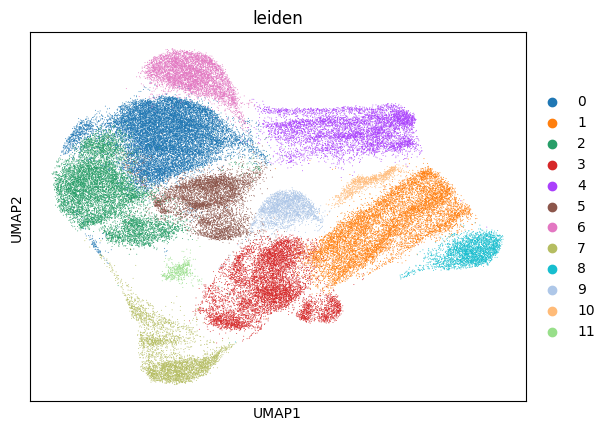

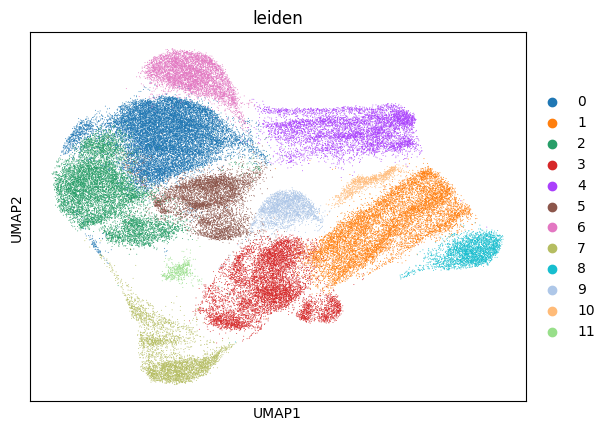

In [86]:
sc.tl.umap(adata_gene)
sc.pl.umap(adata_gene, color=['leiden'])
sc.pl.umap(adata_gene, color=['leiden'])

In [87]:
antigen_colors

{'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.0, 1.0, 0.0),
 'A0201_FLYALALLL_LMP2A_EBV_binder': (1.0, 0.0, 1.0),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.0, 0.5, 1.0),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (1.0, 0.5, 0.0),
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder': (0.5, 0.75, 0.5),
 'A0301_KLGGALQAK_IE-1_CMV_binder': (0.1793537164011899,
  0.0033355078444660125,
  0.6620747897259032),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.73968214343272,
  0.05891730149257346,
  0.3146809676494471),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.349066435944829,
  0.4503226204406996,
  0.013129173322001919),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.8921739233639615,
  0.9978312313940568,
  0.032996100920834937),
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder': (0.0, 1.0, 1.0),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.9677051631643115,
  0.47190225320587564,
  0.729773079807986),
 'unknown': (0.71, 0.71, 0.71)}

In [ ]:
# color_palette = [antigen_colors[cat] for cat in bind_list]
# sc.pl.umap(
#     adata_gene, 
#     color=['antigen'], 
#     palette=antigen_colors
# )

In [88]:
normalized_mutual_info_score(
    adata_gene.obs['leiden'].astype('int').values,
    adata_gene.obs['peptide'].astype('category').cat.codes.values
)

0.4133621840873308

In [89]:
from sklearn.metrics.cluster import adjusted_rand_score
ari_score = adjusted_rand_score(adata_gene.obs['leiden'].astype('int').values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.2626038443392231


In [90]:
adjusted_rand_score(adata_gene.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_gene.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.2626038443392231


In [46]:
all_embed.shape

(115245, 64)

In [47]:
data_10X_dat

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,B0702_GPAESAAGL_NC,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0
CTTGGCTTCGTTGCCT-25,TRAV23DV6,TRBV7-2,None,TRBD1,TRAJ48,TRBJ2-5,TRAC,TRBC2,CAAILFGNEKLTF,CASSLFDSQETQYF,...,0.0,0.0,unknown,nan,1,4585.0,3.661339,1382,0.063250,1
ACGATACTCGCAGGCT-40,TRAV9-2,TRBV7-6,None,TRBD2,TRAJ49,TRBJ2-3,TRAC,TRBC2,CALSADTGNQFYF,CASSLFDSGRLDTQYF,...,0.0,0.0,unknown,nan,2,3742.0,3.573104,1279,0.067611,2
ACGCCAGTCATGTCTT-8,TRAV12-3,TRBV20-1,None,TRBD1,TRAJ32,TRBJ2-7,TRAC,TRBC2,CAMNPAWGGATNKLIF,CSASPGDYEQYF,...,0.0,0.0,unknown,nan,4,4368.0,3.640283,1669,0.054716,3
TTCTTAGCAAAGAATC-4,TRAV13-2,TRBV4-1,None,TRBD2,TRAJ37,TRBJ2-1,TRAC,TRBC2,CAETALGNTGKLIF,CASSHGKGGNEQFF,...,0.0,0.0,unknown,nan,5,9129.0,3.960423,2683,0.044035,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAAGCAGAGCAGGCTA-3,TRAV22,TRBV24-1,None,TRBD2,TRAJ47,TRBJ2-2,TRAC,TRBC2,CAVEPLYGNKLVF,CATSDRLAGGELFF,...,0.0,0.0,unknown,nan,159412,1547.0,3.189490,789,0.135747,145474
CAGTCCTTCATCACCC-8,TRAV29DV5,TRBV7-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAATHASGYDKVIF,CASSYLAGDFTDTQYF,...,0.0,0.0,unknown,nan,159414,3934.0,3.594834,1468,0.041688,145475
GACTACACACGGTAAG-3,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159415,4267.0,3.630123,1646,0.047574,145476


In [22]:
top16_peptide

['unknown',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_FLYALALLL_LMP2A_EBV_binder',
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder',
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder',
 'A0201_RTLNAWVKV_Gag-protein_HIV_binder',
 'A0201_LLFGYPVYV_HTLV-1_binder',
 'A0201_SLFNTVATLY_Gag-protein_HIV_binder',
 'A0201_FLASKIGRLV_Ca2-indepen-Plip-A2_binder',
 'A2402_AYAQKIFKI_IE-1_CMV_binder',
 'A0201_KTWGQYWQV_gp100_Cancer_binder',
 'A0201_YLLEMLWRL_LMP1_EBV_binder',
 'A0201_IMDQVPFSV_gp100_Cancer_binder',
 'A2402_QYDPVAALF_pp65_CMV_binder',
 'A2402_CYTWNQMNL_WT1-(235-243)236M_Y_binder',
 'A0201_MLDLQPETT_16E7_HPV_binder',
 'A0201_KVLEYVIKV_MAGE-A1_Cancer_binder',
 'A0201_RMFPNAPYL_WT-1_binder',
 'A0201_YLNDHLEPWI_BCL-X_Cancer_binder',
 'B3

In [ ]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score
from tqdm import tqdm
adata_emb = ad.AnnData(all_embed)
adata_emb.obs = data_10X_dat
adata_emb = adata_emb[adata_emb.obs.antigen.isin(top16_peptide[1:10])]
# sc.pp.normalize_total(adata_emb, target_sum=1e4)
sc.tl.pca(adata_emb,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([20,25, 30,35 ,40, 45]):
    for resolution in [ 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        for n_neighbors in [5, 10, 15, 20, 25, 30]:
            sc.pp.neighbors(adata_emb, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_emb, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_emb.obs['leiden'].astype('int').values,
                adata_emb.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")
# sc.pl.pca_variance_ratio(adata_emb, log=True)
# sc.pp.neighbors(adata_emb, n_neighbors=3, n_pcs=35)
# sc.tl.leiden(adata_emb, resolution=0.3)
# sc.tl.umap(adata_emb)


In [30]:
data_10X_dat

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,B0702_GPAESAAGL_NC,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0
CTTGGCTTCGTTGCCT-25,TRAV23DV6,TRBV7-2,None,TRBD1,TRAJ48,TRBJ2-5,TRAC,TRBC2,CAAILFGNEKLTF,CASSLFDSQETQYF,...,0.0,0.0,unknown,nan,1,4585.0,3.661339,1382,0.063250,1
ACGATACTCGCAGGCT-40,TRAV9-2,TRBV7-6,None,TRBD2,TRAJ49,TRBJ2-3,TRAC,TRBC2,CALSADTGNQFYF,CASSLFDSGRLDTQYF,...,0.0,0.0,unknown,nan,2,3742.0,3.573104,1279,0.067611,2
ACGCCAGTCATGTCTT-8,TRAV12-3,TRBV20-1,None,TRBD1,TRAJ32,TRBJ2-7,TRAC,TRBC2,CAMNPAWGGATNKLIF,CSASPGDYEQYF,...,0.0,0.0,unknown,nan,4,4368.0,3.640283,1669,0.054716,3
TTCTTAGCAAAGAATC-4,TRAV13-2,TRBV4-1,None,TRBD2,TRAJ37,TRBJ2-1,TRAC,TRBC2,CAETALGNTGKLIF,CASSHGKGGNEQFF,...,0.0,0.0,unknown,nan,5,9129.0,3.960423,2683,0.044035,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GAAGCAGAGCAGGCTA-3,TRAV22,TRBV24-1,None,TRBD2,TRAJ47,TRBJ2-2,TRAC,TRBC2,CAVEPLYGNKLVF,CATSDRLAGGELFF,...,0.0,0.0,unknown,nan,159412,1547.0,3.189490,789,0.135747,145474
CAGTCCTTCATCACCC-8,TRAV29DV5,TRBV7-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAATHASGYDKVIF,CASSYLAGDFTDTQYF,...,0.0,0.0,unknown,nan,159414,3934.0,3.594834,1468,0.041688,145475
GACTACACACGGTAAG-3,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159415,4267.0,3.630123,1646,0.047574,145476


In [36]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score
from tqdm import tqdm
adata_emb = ad.AnnData(all_embed)
adata_emb.obs = data_10X_dat
adata_emb = adata_emb[adata_emb.obs.antigen.isin(donor_all_peptides)]
# sc.pp.normalize_total(adata_emb, target_sum=1e4)
sc.tl.pca(adata_emb,svd_solver='arpack')
best_nmi = 0
best_resolution = 0
best_n_neighbors = 0
for npcs in tqdm([35, 40]):
    for resolution in [ 0.5, 0.6]:
        for n_neighbors in [20, 25, 30]:
            sc.pp.neighbors(adata_emb, n_neighbors=n_neighbors, n_pcs=npcs)
            sc.tl.leiden(adata_emb, resolution=resolution)
            nmi_score = normalized_mutual_info_score(
                adata_emb.obs['leiden'].astype('int').values,
                adata_emb.obs['peptide'].astype('category').cat.codes.values
            )
            print(f"Resolution: {resolution}, N_neighbors: {n_neighbors}, NMI Score: {nmi_score}, PCs: {npcs}")
            if nmi_score > best_nmi:
                best_nmi = nmi_score
                best_resolution = resolution
                best_n_neighbors = n_neighbors
                best_npcs = npcs
print(f"Best NMI Score: {best_nmi} at Resolution: {best_resolution}, N_neighbors: {best_n_neighbors}, PCs: {best_npcs}")
# sc.pl.pca_variance_ratio(adata_emb, log=True)
# sc.pp.neighbors(adata_emb, n_neighbors=3, n_pcs=35)
# sc.tl.leiden(adata_emb, resolution=0.3)
# sc.tl.umap(adata_emb)


/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/phile/miniconda3/envs/integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
  0%|          | 0/2 [00:00<?, ?it/s]

Resolution: 0.5, N_neighbors: 20, NMI Score: 0.4696891152655534, PCs: 35
Resolution: 0.5, N_neighbors: 25, NMI Score: 0.46959195985338303, PCs: 35
Resolution: 0.5, N_neighbors: 30, NMI Score: 0.4691159216940046, PCs: 35
Resolution: 0.6, N_neighbors: 20, NMI Score: 0.46838598414303195, PCs: 35
Resolution: 0.6, N_neighbors: 25, NMI Score: 0.4666042343899572, PCs: 35


 50%|█████     | 1/2 [06:34<06:34, 394.83s/it]

Resolution: 0.6, N_neighbors: 30, NMI Score: 0.46784319035981026, PCs: 35
Resolution: 0.5, N_neighbors: 20, NMI Score: 0.4665575780501836, PCs: 40
Resolution: 0.5, N_neighbors: 25, NMI Score: 0.46801660867673944, PCs: 40
Resolution: 0.5, N_neighbors: 30, NMI Score: 0.4681008114274247, PCs: 40
Resolution: 0.6, N_neighbors: 20, NMI Score: 0.4678193201456444, PCs: 40
Resolution: 0.6, N_neighbors: 25, NMI Score: 0.4682993401631396, PCs: 40


100%|██████████| 2/2 [12:01<00:00, 360.60s/it]

Resolution: 0.6, N_neighbors: 30, NMI Score: 0.46894399024256217, PCs: 40
Best NMI Score: 0.4696891152655534 at Resolution: 0.5, N_neighbors: 20, PCs: 35


In [57]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0,9
CTGCGGATCGACAGCC-31,TRAV14DV4,TRBV4-3,None,TRBD1,TRAJ28,TRBJ1-2,TRAC,TRBC1,CAMREPYSGAGSYQLTF,CASSQDRQGISIGYTF,...,1.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,6,2995.0,3.476397,1527,0.064775,5,1
GAGCAGAAGCGTGAGT-37,TRAV36DV7,TRBV9,None,TRBD1,TRAJ54,TRBJ1-1,TRAC,TRBC1,CAHLQGAQKLVF,CASSEGDRVTEAFF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,10,3915.0,3.592732,1624,0.028097,9,5
TGAAAGATCGAGAACG-32,TRAV16,TRBV29-1,None,TRBD1,TRAJ53,TRBJ2-2,TRAC,TRBC2,CALSGGSNYKLTF,CSDRGGTGELFF,...,0.0,A0201_GILGFVFTL_Flu-MP_Influenza_binder,GILGFVFTL,12,8505.0,3.929674,2151,0.067372,11,6
CGATGTACAGTTCATG-28,TRAV16,TRBV11-2,None,TRBD1,TRAJ49,TRBJ1-2,TRAC,TRBC1,CAPGNQFYF,CASSWGGGSHYGYTF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,13,1827.0,3.261739,1015,0.121511,12,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTTCGACAGAGTGTG-6,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159387,3141.0,3.497068,1761,0.087552,145450,7
TTCTCCTTCCACGACG-7,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159389,5594.0,3.747722,1915,0.055417,145452,7
TCAGCAATCCTGCAGG-5,TRAV8-4,TRBV6-6,None,TRBD2,TRAJ10,TRBJ2-3,TRAC,TRBC2,CAVFTGGGNKLTF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159401,2433.0,3.386142,1441,0.090834,145463,7


In [58]:
adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

0.2272704878063046

NMI Score: 0.42414366644305646


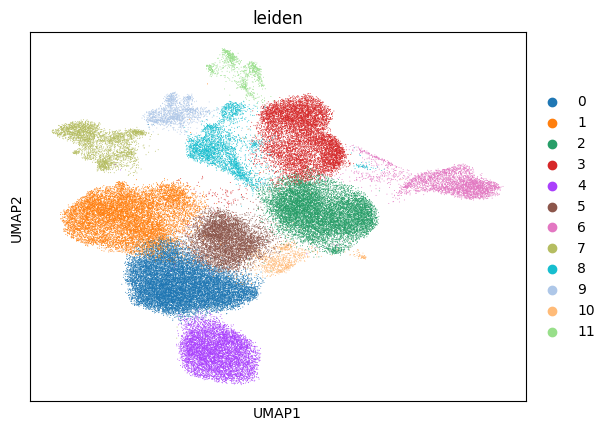

In [59]:
sc.pp.neighbors(adata_emb, n_neighbors = best_n_neighbors, n_pcs=best_npcs)
sc.tl.leiden(adata_emb, resolution=best_resolution)
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")
sc.tl.umap(adata_emb)
sc.pl.umap(adata_emb, color=['leiden'])

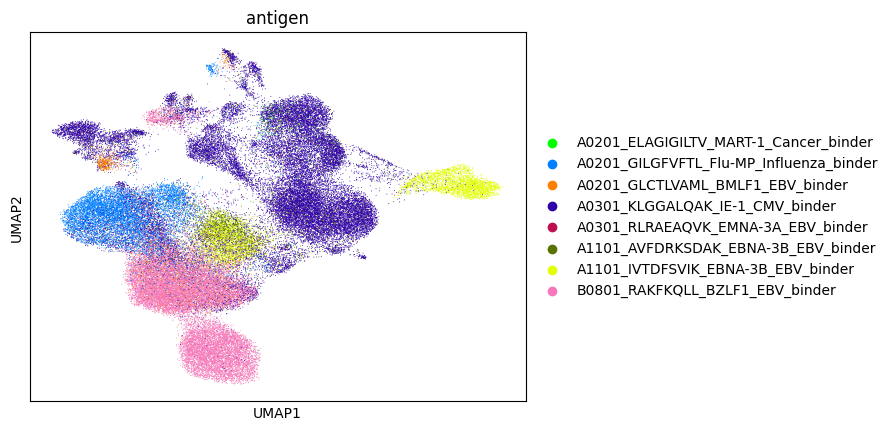

In [60]:
antigen_colors = {'A0201_ELAGIGILTV_MART-1_Cancer_binder': (0.0, 1.0, 0.0),
 'A0201_FLYALALLL_LMP2A_EBV_binder': (1.0, 0.0, 1.0),
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder': (0.0, 0.5, 1.0),
 'A0201_GLCTLVAML_BMLF1_EBV_binder': (1.0, 0.5, 0.0),
 'A0201_LLDFVRFMGV_EBNA-3B_EBV_binder': (0.5, 0.75, 0.5),
 'A0301_KLGGALQAK_IE-1_CMV_binder': (0.1793537164011899,
  0.0033355078444660125,
  0.6620747897259032),
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder': (0.73968214343272,
  0.05891730149257346,
  0.3146809676494471),
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder': (0.349066435944829,
  0.4503226204406996,
  0.013129173322001919),
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder': (0.8921739233639615,
  0.9978312313940568,
  0.032996100920834937),
 'B0801_FLRGRAYGL_EBNA-3A_EBV_binder': (0.0, 1.0, 1.0),
 'B0801_RAKFKQLL_BZLF1_EBV_binder': (0.9677051631643115,
  0.47190225320587564,
  0.729773079807986),
 'unknown': (0.71, 0.71, 0.71)}
sc.pl.umap(
    adata_emb, 
    color=['antigen'], 
    palette=antigen_colors
)

In [61]:
# adata_emb.obs['antigen_color'] = [antigen_colors[x] for x in adata_emb.obs['antigen'].values]
# adata_emb.obs

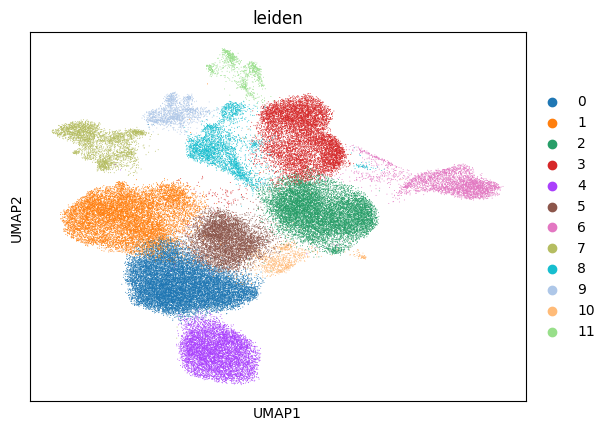

In [62]:
sc.pl.umap(adata_emb, color=['leiden'])

In [63]:
adata_emb.obs['antigen'].value_counts()

antigen
A0301_KLGGALQAK_IE-1_CMV_binder            29017
B0801_RAKFKQLL_BZLF1_EBV_binder            19242
A0201_GILGFVFTL_Flu-MP_Influenza_binder     8440
A1101_IVTDFSVIK_EBNA-3B_EBV_binder          6119
A1101_AVFDRKSDAK_EBNA-3B_EBV_binder         3939
A0201_GLCTLVAML_BMLF1_EBV_binder            1535
A0301_RLRAEAQVK_EMNA-3A_EBV_binder           431
A0201_ELAGIGILTV_MART-1_Cancer_binder        265
Name: count, dtype: int64

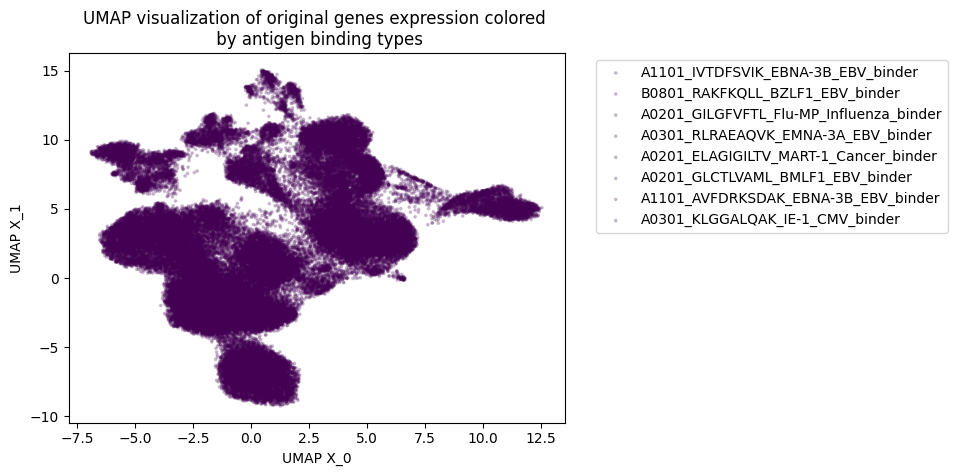

In [64]:
uniq = list(set(adata_emb.obs['antigen'].values))
alpha = 0.2

for i in range(len(uniq)):
    indx = adata_emb.obs['antigen'] == uniq[i]
    plt.scatter(adata_emb.obsm['X_umap'][list(indx),0], adata_emb.obsm['X_umap'][list(indx),1], s=3, c=adata_emb.obs['antigen'].astype('category').cat.codes.values[indx],label=uniq[i], alpha=alpha)

plt.xlabel('UMAP X_0')
plt.ylabel('UMAP X_1')
plt.title('UMAP visualization of original genes expression colored \n by antigen binding types')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))
plt.show()

In [65]:
adata_emb.obs

,v_gene_TRA,v_gene_TRB,d_gene_TRA,d_gene_TRB,j_gene_TRA,j_gene_TRB,c_gene_TRA,c_gene_TRB,cdr3_TRA,cdr3_TRB,...,NR(B0801)_AAKGRGAAL_NC,antigen,peptide,orig_ix,n_counts,log_counts,n_genes,mt_fraction,used_ix,leiden
barcode,,,,,,,,,,,,,,,,,,,,,
AGGGTGAGTATTACCG-18,TRAV19,TRBV20-1,None,TRBD2,TRAJ40,TRBJ2-3,TRAC,TRBC2,CALSEASGTYKYIF,CSAPSGEGRDTQYF,...,0.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,0,5478.0,3.738622,1830,0.058050,0,7
CTGCGGATCGACAGCC-31,TRAV14DV4,TRBV4-3,None,TRBD1,TRAJ28,TRBJ1-2,TRAC,TRBC1,CAMREPYSGAGSYQLTF,CASSQDRQGISIGYTF,...,1.0,A0301_KLGGALQAK_IE-1_CMV_binder,KLGGALQAK,6,2995.0,3.476397,1527,0.064775,5,0
GAGCAGAAGCGTGAGT-37,TRAV36DV7,TRBV9,None,TRBD1,TRAJ54,TRBJ1-1,TRAC,TRBC1,CAHLQGAQKLVF,CASSEGDRVTEAFF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,10,3915.0,3.592732,1624,0.028097,9,5
TGAAAGATCGAGAACG-32,TRAV16,TRBV29-1,None,TRBD1,TRAJ53,TRBJ2-2,TRAC,TRBC2,CALSGGSNYKLTF,CSDRGGTGELFF,...,0.0,A0201_GILGFVFTL_Flu-MP_Influenza_binder,GILGFVFTL,12,8505.0,3.929674,2151,0.067372,11,3
CGATGTACAGTTCATG-28,TRAV16,TRBV11-2,None,TRBD1,TRAJ49,TRBJ1-2,TRAC,TRBC1,CAPGNQFYF,CASSWGGGSHYGYTF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,13,1827.0,3.261739,1015,0.121511,12,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTTCGACAGAGTGTG-6,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159387,3141.0,3.497068,1761,0.087552,145450,6
TTCTCCTTCCACGACG-7,TRAV21,TRBV6-6,None,TRBD2,TRAJ50,TRBJ2-3,TRAC,TRBC2,CAVDLMKTSYDKVIF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159389,5594.0,3.747722,1915,0.055417,145452,6
TCAGCAATCCTGCAGG-5,TRAV8-4,TRBV6-6,None,TRBD2,TRAJ10,TRBJ2-3,TRAC,TRBC2,CAVFTGGGNKLTF,CASRTGLASTDTQYF,...,0.0,A1101_IVTDFSVIK_EBNA-3B_EBV_binder,IVTDFSVIK,159401,2433.0,3.386142,1441,0.090834,145463,6


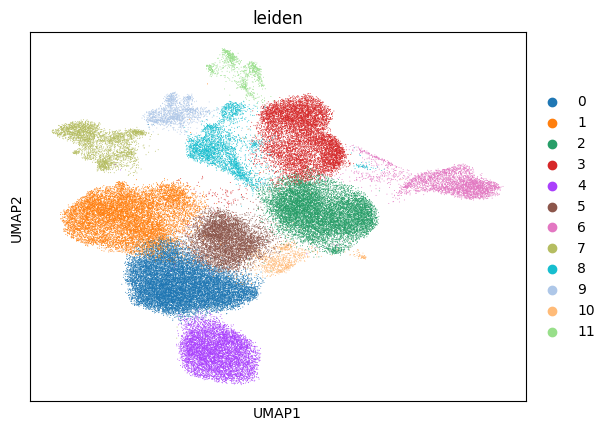

In [66]:
sc.pl.umap(adata_emb, color=['leiden'])

In [67]:
# sc.pl.umap(adata_emb, color=['IR_VDJ_1_junction_aa'])

In [68]:
# data_10X_dat[['cdr3b','Peptide_sequence']].groupby('cdr3b').value_counts().sort_values(ascending=False)

In [69]:
# data_10X_dat[data_10X_dat.cdr3b == "CASSLGFPNQPQHF"]        

In [70]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "TTDPSFLGRY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts().sort_values(ascending=False)        

In [71]:
# data_10X_dat[data_10X_dat.Peptide_sequence == "LTDEMIAQY"].groupby('cdr3b')[['cdr3b','Peptide_sequence']].value_counts()        

In [72]:
from sklearn.metrics.cluster import normalized_mutual_info_score

In [73]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.42414366644305646


In [74]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.34727380721575457


In [75]:
nmi_score = normalized_mutual_info_score(adata_emb.obs['cdr3_TRA'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"NMI Score: {nmi_score}")

NMI Score: 0.34538370088731024


In [76]:
ari_score = adjusted_rand_score(adata_emb.obs['leiden'].astype('int').values, adata_emb.obs['peptide'].astype('category').cat.codes.values)
print(f"ARI Score: {ari_score}")

ARI Score: 0.28916139601457


In [77]:
adjusted_rand_score(adata_emb.obs['cdr3_TRB'].astype('category').cat.codes.values, adata_emb.obs['peptide'].astype('category').cat.codes.values)

0.0890407297825544

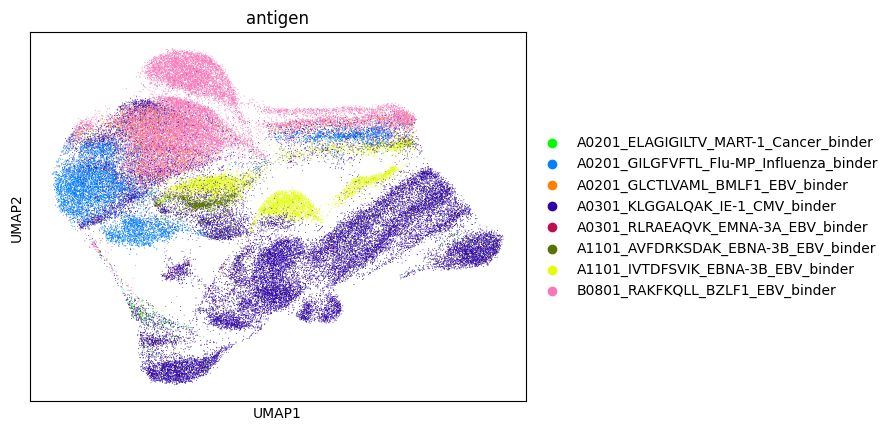

In [91]:
sc.pl.umap(
    adata_gene, 
    color=['antigen'], 
    palette=antigen_colors
)